In [1]:
import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord

In [2]:
p_25 = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_0p25bar-m09.nc?download=1')
air_tempp = p_25[6]

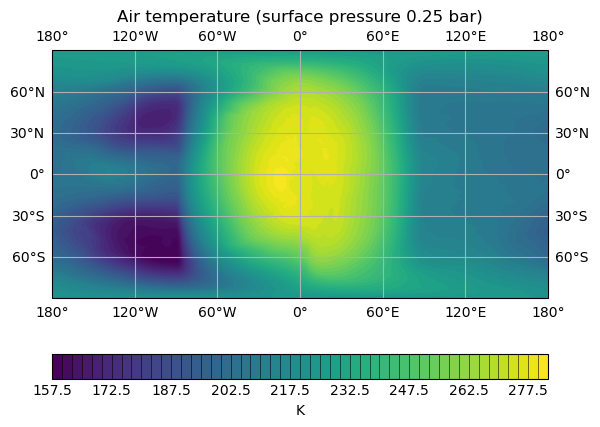

In [3]:
qplt.contourf(air_tempp[0], 50)

plt.gca().gridlines(draw_labels=True)
plt.title('Air temperature (surface pressure 0.25 bar)')
plt.show()

In [4]:
air_tempp_roll = aeolus.coord.roll_cube_pm180(air_tempp, add_shift=0)
air_tempp_roll[0].ndim
air_tempp_roll0 = air_tempp_roll[0]

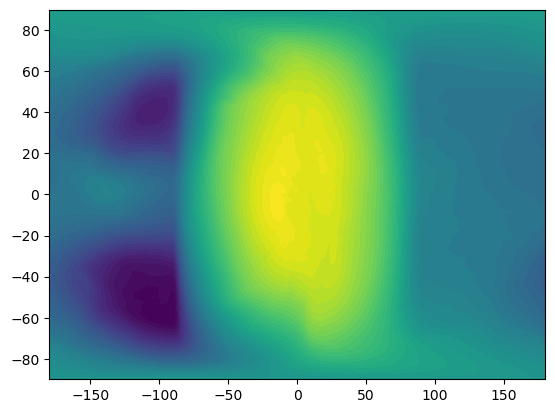

In [5]:
# contour = iplt.contour(air_tempp_roll[0])

x = air_tempp_roll0.coord('longitude').points
y = air_tempp_roll0.coord('latitude').points

data = air_tempp_roll0.data

X, Y = np.meshgrid(x, y)

plt.contourf(x, y, data, 50)

# plt.gca().gridlines(draw_labels=True)
plt.show()

In [6]:
dayside = air_tempp_roll.extract(iris.Constraint(longitude=lambda v:  (-75<= v <= 75)))
# dayside.ndim

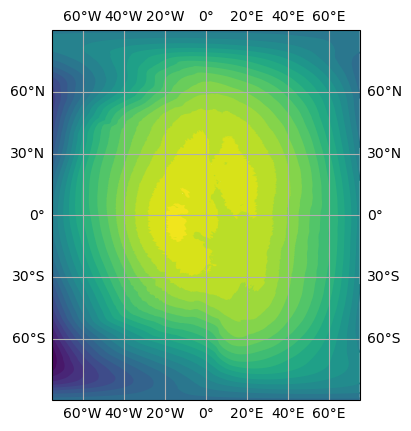

In [7]:
iplt.contourf(dayside[0], 25)

plt.gca().gridlines(draw_labels=True)
plt.show()

In [8]:
# dayside.coord('latitude').guess_bounds()
# dayside.coord('longitude').guess_bounds()
# grid_areas = iris.analysis.cartography.area_weights(dayside)

In [9]:
new_dayside = dayside.collapsed(['longitude', 'latitude'], iris.analysis.MEAN)

/home/jj22956/.local/lib/python3.12/site-packages/iris/cube.py:4447: IrisUserWarning: Collapsing spatial coordinate 'latitude' without weighting
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'latitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'latitude'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'longitude', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'longitude'. Ignoring bounds.
  warnings.warn(


In [10]:
print(new_dayside.coord('level_height').points)

[   26.929874      71.81659028   134.64936449   215.43899423
   314.18545741   430.87798846   565.52734743   718.13353431
   888.68585534  1077.19491592  1283.66093697  1508.07292647
  1750.44176598  2010.76751074  2289.03933441  2585.26789762
  2899.45325561  3231.58480299  3581.67320037  3949.71822682
  4335.70988455  4739.6579504   5161.56286626  5601.41413722
  6059.22154012  6534.98629015  7028.69678769  7540.36408
  8069.9892718   8617.55965875  9183.08739283  9766.58186423
 10368.0546726  10987.57099686 11625.2286054  12281.24015829
 12955.90835088 13649.71981569 14363.38268312 15097.87850362
 15854.56443506 16635.26162088 17442.34909198 18278.86816343
 19148.68096293 20056.60410281 21008.60863575 22011.95206971
 23075.4341124  24209.5911033 ]


In [11]:
sample_points = [('level_height', np.linspace(400, 1250, 10))]
new_column = new_dayside.interpolate(sample_points, iris.analysis.Linear())

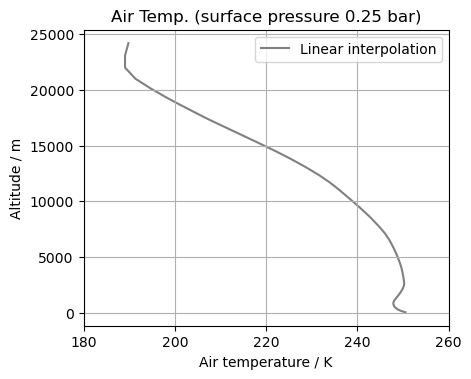

In [13]:
alt_coord = new_dayside.coord("level_height")

# Interpolate the "perfect" linear interpolation. Really this is just
# a high number of interpolation points, in this case 1000 of them.
altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

# Now interpolate the data onto 10 evenly spaced altitude levels,
# as we did in the example.
altitude_points = [("level_height", np.linspace(25, 24210, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

# Plot the black markers for the original data.
# qplt.plot(
#     new_dayside,
#     marker="o",
#     color="black",
#     linestyle="",
#     markersize=3,
#     label="Original values",
#     zorder=2,
# )

# Plot the gray line to display the linear interpolation.
qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

# Plot the red markers for the new data.
# qplt.plot(
#     new_column,
#     marker="D",
#     color="red",
#     linestyle="",
#     label="Interpolated values",
#     zorder=1,
# )

ax = plt.gca()
# Space the plot such that the labels appear correctly.
plt.subplots_adjust(left=0.17, bottom=0.14)

# Limit the plot to a maximum of 5 ticks.
ax.xaxis.get_major_locator().set_params(nbins=5)

# Prevent matplotlib from using "offset" notation on the xaxis.
ax.xaxis.get_major_formatter().set_useOffset(False)

# Put some space between the line and the axes.
ax.margins(0.05)

# Place gridlines and a legend.
ax.grid()
plt.legend(loc="upper right")
plt.title('Air Temp. (surface pressure 0.25 bar)')
plt.ylabel('Altitude / m')
plt.xlim(180, 260)
plt.show()

In [16]:
strat_temps = pd.read_csv('/data/cluster4/jj22956/thunderstruck_files/stratosphere_temperature_array')
strat_alts = pd.read_csv('/data/cluster4/jj22956/thunderstruck_files/stratosphere_altitude_array')

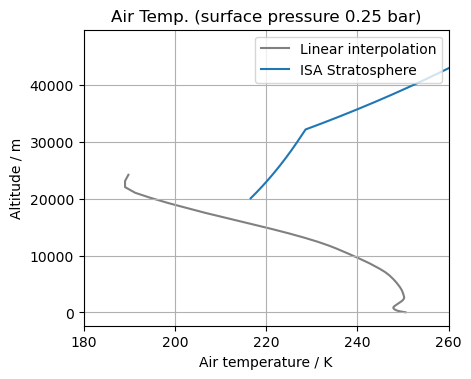

In [18]:
alt_coord = new_dayside.coord("level_height")

altitude_points = [
    (
        "level_height",
        np.linspace(min(alt_coord.points), max(alt_coord.points), 1000),
    )
]
scheme = iris.analysis.Linear()
linear_column = new_dayside.interpolate(altitude_points, scheme)

altitude_points = [("level_height", np.linspace(25, 24210, 10))]
scheme = iris.analysis.Linear()
new_column = new_dayside.interpolate(altitude_points, scheme)

plt.figure(figsize=(5, 4), dpi=100)

qplt.plot(
    linear_column,
    color="gray",
    label="Linear interpolation",
    zorder=0,
)

plt.plot(
    strat_temps, strat_alts,
    label= "ISA Stratosphere"
)

ax = plt.gca()
plt.subplots_adjust(left=0.17, bottom=0.14)

ax.xaxis.get_major_locator().set_params(nbins=5)

ax.xaxis.get_major_formatter().set_useOffset(False)

ax.margins(0.05)

ax.grid()
plt.legend(loc="upper right")
plt.title('Air Temp. (surface pressure 0.25 bar)')
plt.ylabel('Altitude / m')
plt.xlim(180, 260)
plt.show()